# Clasificación multiclase

## Introduction

En este ejercicio se implementa la regresion one-vs-all
Antes de empezar la ejecución de las partes de codigo correspondienters a los ejercicios, se requiere importar todas las librerias necesarias.

In [ ]:
# Conectamos nuestro Google Drive para acceder a los datasets
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Librerías principales
import pandas as pd            # Para cargar CSV
import numpy as np             # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para mostrar imágenes
from scipy import optimize     # Para entrenamiento

%matplotlib inline

## 1 Clasificación multiclase

Para este ejercicio, se usará regresión logística y redes neuronales para reconocer dígitos escritos a mano (de 0 a 9). El reconocimiento automático de dígitos escritos a mano se usa ampliamente en la actualidad, desde el reconocimiento de códigos postales (códigos postales) en sobres de correo hasta el reconocimiento de montos escritos en cheques bancarios. Este ejercicio  mostrará cómo los métodos que ha aprendido se pueden utilizar para esta tarea de clasificación.

La primera parte del ejercicio, extenderá la implementación anterior de la regresión logística y la aplicará a la clasificación de uno contra todos (one vs all).

### 1.1 Dataset

Se proporciona un conjunto de datos en `ex3data1.mat` que contiene 5000 ejemplos de entrenamiento de dígitos escritos a mano (este es un subconjunto del conjunto de datos de dígitos escritos a mano [MNIST] http://yann.lecun.com/exdb/mnist)). El formato `.mat` significa que los datos se han guardado en un formato de matriz nativo Octave/MATLAB, en lugar de un formato de texto (ASCII) como un archivo csv. Usamos el formato `.mat` aquí para mostrar los diferentes formatos en los que se pueden presentar los datasets. Python proporciona mecanismos para cargar el formato nativo de MATLAB usando la función `loadmat` dentro del módulo` scipy.io`. Esta función devuelve un diccionario de Python con claves que contienen los nombres de las variables dentro del archivo `.mat`.

Hay 5000 ejemplos de entrenamiento en `ex3data1.mat`, donde cada ejemplo de entrenamiento es una imagen en escala de grises de 20 píxeles por 20 píxeles del dígito. Cada píxel está representado por un número de punto flotante que indica la intensidad de la escala de grises en esa ubicación. La cuadrícula de 20 por 20 píxeles se "desenrolla" en un vector de 400 dimensiones. Cada uno de estos ejemplos de entrenamiento se convierte en una sola fila en nuestra matriz de datos "X". Esto da una matriz `X` de 5000 por 400 donde cada fila es un ejemplo de entrenamiento para una imagen de dígitos escrita a mano.

$$ X = \begin{bmatrix} - \: (x^{(1)})^T \: - \\ -\: (x^{(2)})^T \:- \\ \vdots \\ - \: (x^{(m)})^T \:-  \end{bmatrix} $$

La segunda parte del conjunto de entrenamiento es un vector "y" de 5000 dimensiones que contiene etiquetas para el conjunto de entrenamiento.

Se inicia el ejercicio cargando primero el conjunto de datos.

In [ ]:
# Importar la librería de Google Colab para montar Google Drive
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/colab/lab4/'


# Cargar los archivos CSV con pandas

# Cargar las imágenes de entrenamiento
# Cada fila es una imagen aplanada (28x28 = 784 pixeles)
# header=None indica que el CSV no tiene fila de encabezado
X_train = pd.read_csv(path + 'csvTrainImages 60k x 784.csv', header=None)

# Cargar las etiquetas (números del 0 al 9) correspondientes a las imágenes de entrenamiento
# Cada fila indica el dígito de la imagen en la misma posición
y_train = pd.read_csv(path + 'csvTrainLabel 60k x 1.csv', header=None)

# Cargar las imágenes de prueba
# 10,000 imágenes, mismas características que X_train (28x28 aplanadas = 784 columnas)
X_test = pd.read_csv(path + 'csvTestImages 10k x 784.csv', header=None)

# Cargar las etiquetas de prueba
# Cada fila indica el dígito correcto de la imagen en X_test
y_test = pd.read_csv(path + 'csvTestLabel 10k x 1.csv', header=None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Convertir los DataFrames de pandas a arrays de NumPy

#Convertir a arrays de NumPy
import numpy as np

X_train = X_train.to_numpy()
y_train = y_train.to_numpy().ravel()  # ravel convierte (m,1) → (m,)
X_test = X_test.to_numpy()
y_test = y_test.to_numpy().ravel()

# Mostrar tamaños
print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test X:", X_test.shape, "Test y:", y_test.shape)

# Agregar columna de 1's para bias
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

print("Nuevo tamaño X_train con bias:", X_train.shape)
print("Nuevo tamaño X_test con bias:", X_test.shape)

Train X: (60000, 784) Train y: (60000,)
Test X: (10000, 784) Test y: (10000,)
Nuevo tamaño X_train con bias: (60000, 785)
Nuevo tamaño X_test con bias: (10000, 785)


Dimensiones entrenamiento: (48000, 785) (48000,)
Dimensiones validación: (12000, 785) (12000,)


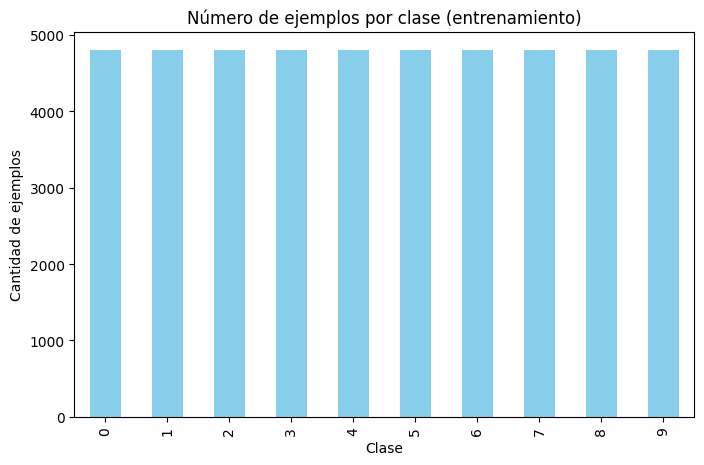

In [ ]:
# Dividir dataset en entrenamiento y validación
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Separamos 80% para entrenamiento y 20% para validación
# stratify=y_train asegura que cada clase tenga la misma proporción en ambos conjuntos
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,         # Datos de entrada (imágenes)
    y_train,         # Etiquetas (0-9)
    test_size=0.2,   # 20% para validación
    random_state=42, # Semilla para reproducibilidad
    stratify=y_train # Mantener proporción de clases
)

# Imprimimos las dimensiones de los conjuntos
print("Dimensiones entrenamiento:", X_train_split.shape, y_train_split.shape)
print("Dimensiones validación:", X_val.shape, y_val.shape)

# Verificar balance de clases en el conjunto de entrenamiento

plt.figure(figsize=(8,5))

# Contar cuántos ejemplos hay de cada clase y ordenarlos de 0 a 9
pd.Series(y_train_split).value_counts().sort_index().plot(
    kind='bar',       # Gráfico de barras
    color='skyblue'   # Color de las barras
)

plt.title("Número de ejemplos por clase (entrenamiento)")
plt.xlabel("Clase")       # Etiqueta eje X
plt.ylabel("Cantidad de ejemplos")  # Etiqueta eje Y
plt.show()

Números correspondientes a estas imágenes:
[0 2 1 8 5 7 9 4 4 2 4 5 6 9 9 7 4 5 8 9 1 1 6 2 4 4 7 0 2 6 7 0 8 1 0 1 4
 2 6 9 6 1 4 9 6 3 9 8 7 4 7 9 4 4 1 1 2 2 4 7 4 6 0 4 2 3 3 8 7 0 3 7 2 2
 9 3 1 3 6 5 8 8 0 1 9 4 3 8 1 9 2 8 1 1 5 1 7 3 1 3]


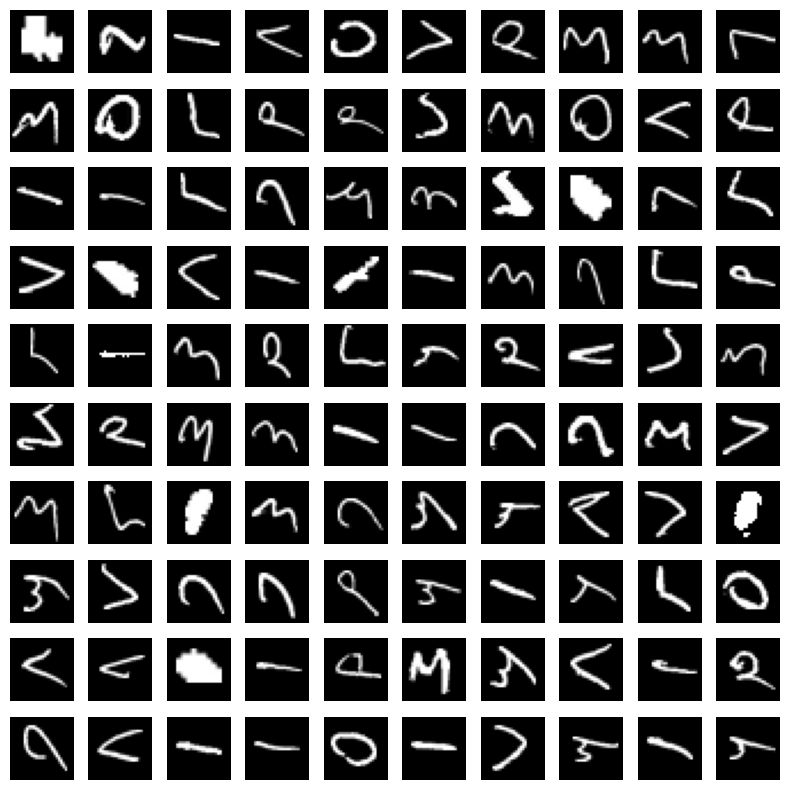

In [ ]:
# Función para mostrar imágenes en cuadrícula con sus etiquetas
import matplotlib.pyplot as plt
import numpy as np

def displayDataWithNumbers(X, y=None, example_width=28, figsize=(8,8)):
    """
    Muestra imágenes en una cuadrícula y opcionalmente las etiquetas correspondientes.

    X: matriz (m x n) con imágenes (incluye columna de bias)
    y: vector (m,) con etiquetas, o None si no hay
    example_width: ancho de cada imagen en píxeles
    figsize: tamaño de la figura para matplotlib
    """
    m, n = X.shape  # m = número de imágenes, n = número de características (píxeles)
    example_height = n // example_width  # calcular altura de la imagen

    # Calcular filas y columnas de la cuadrícula
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    if y is not None:
        print("Números correspondientes a estas imágenes:")
        print(y)

    # Crear figura y ejes
    fig, axarr = plt.subplots(display_rows, display_cols, figsize=figsize)
    axarr = axarr.flatten()  # Convertir a 1D para iterar fácilmente

    for i in range(display_rows * display_cols):
        if i < m:
            # Ignorar la primera columna (bias) y dar forma a la imagen
            axarr[i].imshow(X[i,1:].reshape(example_width, example_height), cmap='gray')
            axarr[i].axis('off')  # Quitar ejes

    plt.tight_layout()
    plt.show()
# Selección aleatoria de 100 imágenes para visualizar
# np.random.choice selecciona índices aleatorios sin reemplazo
indices = np.random.choice(X_train_split.shape[0], 100, replace=False)
X_sample = X_train_split[indices]  # Imágenes seleccionadas
y_sample = y_train_split[indices]  # Etiquetas correspondientes

# Mostrar las imágenes con la función definida
displayDataWithNumbers(X_sample, y_sample)

In [ ]:
def sigmoid(z):
    """
    La sigmoide transforma cualquier valor real z en un valor entre 0 y 1,

    """
    return 1 / (1 + np.exp(-z))

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Función de costo y gradiente para regresión logística con regularización L2.

    Parámetros:
    - theta: vector de parámetros (n x 1)
    - X: matriz de características (m x n), donde cada fila es un ejemplo
    - y: vector de etiquetas (m,)
    - lambda_: parámetro de regularización

    Retorna:
    - J: valor escalar del costo
    - grad: vector del mismo tamaño que theta con los gradientes
    """


    # Número de ejemplos
    m = y.size  # cantidad de ejemplos (filas de X)


    # Calcular predicciones usando la sigmoide

    # h = sigmoid(X * theta) → h(x) = σ(theta^T * x)
    # Devuelve un vector de tamaño m con probabilidades de clase 1
    h = sigmoid(X.dot(theta))


    # Preparar theta para regularización

    temp = theta.copy()  # hacemos una copia para no modificar theta original
    temp[0] = 0          # no penalizamos el bias (theta0)


    # Función de costo con regularización

    # Fórmula sin regularización:
    # J = (1/m) * Σ[-y_i * log(h_i) - (1 - y_i) * log(1 - h_i)]
    # Con regularización L2 (excepto bias):
    # J = (1/m) * Σ[-y_i * log(h_i) - (1 - y_i) * log(1 - h_i)] + (λ / 2m) * Σ(theta_j^2)

    J = (1/m) * (-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) \
        + (lambda_ / (2*m)) * np.sum(temp**2)


    # Gradiente (derivada de J con respecto a theta)

    # grad = (1/m) * X^T * (h - y) + (lambda/m) * temp
    # Nota: temp[0] = 0 → grad[0] no se regulariza
    grad = (1/m) * (X.T.dot(h - y)) + (lambda_/m) * temp

    return J, grad

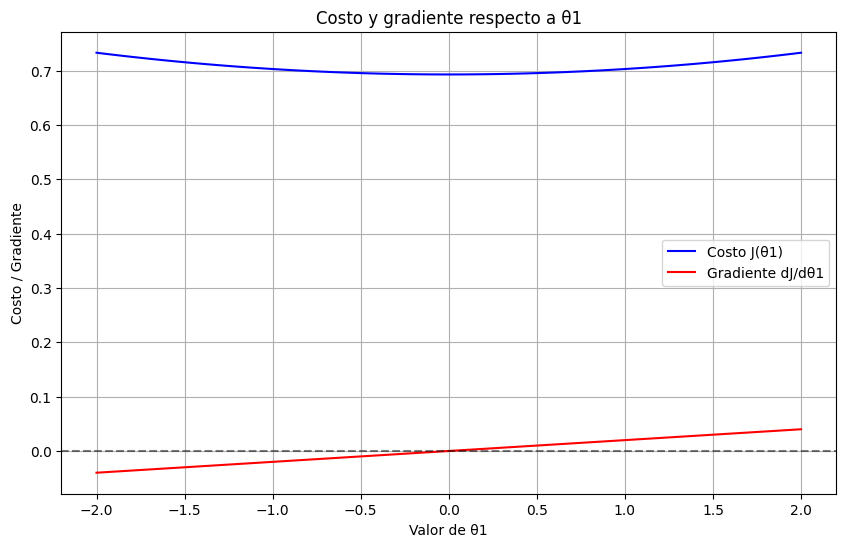

'\nCurva azul → Costo J(θ1)\n\nMuestra cómo cambia el costo al variar θ1.\n\nEl mínimo de esta curva corresponde al valor de θ1 que mejor ajusta los datos.\n\nConvexa → un solo mínimo global (propiedad de la regresión logística binaria).\n\nCurva roja → Gradiente dJ/dθ1\n\nMuestra la pendiente del costo con respecto a θ1 en cada punto.\n\nCuando gradiente > 0 → θ1 es demasiado grande → el optimizador debe disminuir θ1\n\nCuando gradiente < 0 → θ1 es demasiado pequeño → el optimizador debe aumentar θ1\n\nCruce de la línea de gradiente con cero → punto donde J(θ1) tiene mínimo (gradiente = 0)\n\nInterpretación\n\nEl gradiente indica dirección de actualización: es lo que usan los optimizadores para ajustar θ durante entrenamiento.\n\nEl mínimo de J coincide con donde gradiente = 0.\n\nEste gráfico es un ejemplo didáctico con solo 5 imágenes y variando un parámetro para poder visualizarlo.\n'

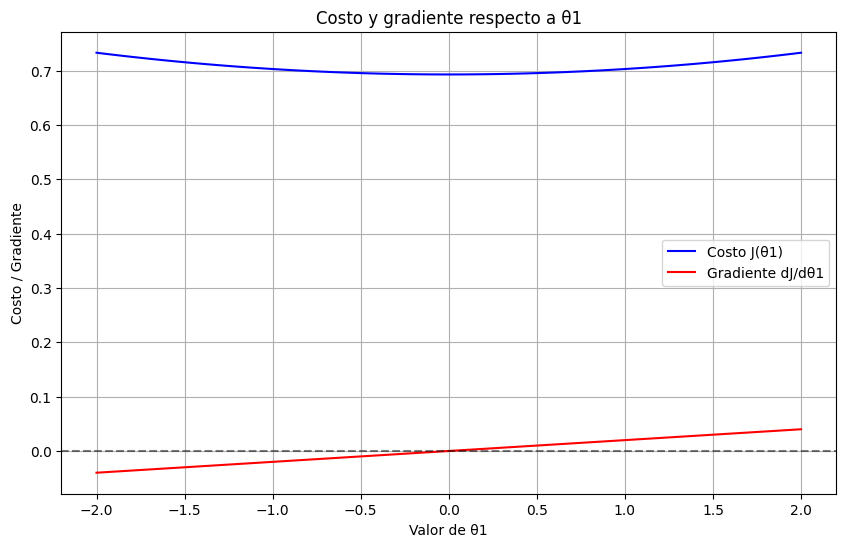

'\nCurva azul → Costo J(θ1)\n\nMuestra cómo cambia el costo al variar θ1.\n\nEl mínimo de esta curva corresponde al valor de θ1 que mejor ajusta los datos.\n\nConvexa → un solo mínimo global (propiedad de la regresión logística binaria).\n\nCurva roja → Gradiente dJ/dθ1\n\nMuestra la pendiente del costo con respecto a θ1 en cada punto.\n\nCuando gradiente > 0 → θ1 es demasiado grande → el optimizador debe disminuir θ1\n\nCuando gradiente < 0 → θ1 es demasiado pequeño → el optimizador debe aumentar θ1\n\nCruce de la línea de gradiente con cero → punto donde J(θ1) tiene mínimo (gradiente = 0)\n\nInterpretación\n\nEl gradiente indica dirección de actualización: es lo que usan los optimizadores para ajustar θ durante entrenamiento.\n\nEl mínimo de J coincide con donde gradiente = 0.\n\nEste gráfico es un ejemplo didáctico con solo 5 imágenes y variando un parámetro para poder visualizarlo.\n'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos un conjunto pequeño para visualizar
X_example = X_train[:5]                     # 5 ejemplos
y_example = (y_train[:5] == 0).astype(int)  # binarizamos: clase 0 = 1, resto = 0

# Inicializamos theta en cero
theta_init = np.zeros(X_example.shape[1])
lambda_ = 0.1

# Valores de theta1 a evaluar
theta_range = np.linspace(-2, 2, 100)  # 100 puntos
cost_values = []
grad_values = []

for t in theta_range:
    theta_temp = theta_init.copy()
    theta_temp[1] = t  # solo variamos θ1
    J, grad = lrCostFunction(theta_temp, X_example, y_example, lambda_)
    cost_values.append(J)
    grad_values.append(grad[1])  # gradiente respecto a θ1

# Graficar costo y gradiente
plt.figure(figsize=(10,6))
plt.plot(theta_range, cost_values, label="Costo J(θ1)", color='blue')
plt.plot(theta_range, grad_values, label="Gradiente dJ/dθ1", color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Valor de θ1")
plt.ylabel("Costo / Gradiente")
plt.title("Costo y gradiente respecto a θ1")
plt.legend()
plt.grid(True)
plt.show()
'''
Curva azul → Costo J(θ1)

Muestra cómo cambia el costo al variar θ1.

El mínimo de esta curva corresponde al valor de θ1 que mejor ajusta los datos.

Convexa → un solo mínimo global (propiedad de la regresión logística binaria).

Curva roja → Gradiente dJ/dθ1

Muestra la pendiente del costo con respecto a θ1 en cada punto.

Cuando gradiente > 0 → θ1 es demasiado grande → el optimizador debe disminuir θ1

Cuando gradiente < 0 → θ1 es demasiado pequeño → el optimizador debe aumentar θ1

Cruce de la línea de gradiente con cero → punto donde J(θ1) tiene mínimo (gradiente = 0)

Interpretación

El gradiente indica dirección de actualización: es lo que usan los optimizadores para ajustar θ durante entrenamiento.

El mínimo de J coincide con donde gradiente = 0.

Este gráfico es un ejemplo didáctico con solo 5 imágenes y variando un parámetro para poder visualizarlo.
'''

In [ ]:
from scipy import optimize  # Librería para optimización numérica

# Lista global para guardar la evolución del costo de cada clase
cost_history_all = []

def oneVsAll_with_cost(X, y, num_labels, lambda_):
    """
    Entrena 'num_labels' clasificadores de regresión logística (One-vs-All)
    y guarda la evolución del costo por clase.

    Parámetros:
    X          : matriz de características (m x n) incluyendo bias
    y          : vector de etiquetas (m,)
    num_labels : número de clases (10 para dígitos 0-9)
    lambda_    : parámetro de regularización

    Devuelve:
    all_theta  : matriz de pesos (theta) entrenados, una fila por clase
    """
    m, n = X.shape  # m = número de ejemplos, n = número de características (incluyendo bias)
    all_theta = np.zeros((num_labels, n))  # Inicializar theta para todas las clases

    # Entrenar un clasificador por cada clase
    for c in range(num_labels):
        print(f"Entrenando clase {c} ...")

        # Inicialización de theta en ceros
        initial_theta = np.zeros(n)

        # Crear etiquetas binarizadas para la clase c (1 si pertenece, 0 si no)
        y_c = (y == c).astype(int)

        # Lista para almacenar evolución del costo durante la optimización
        cost_history = []

        # Callback para registrar el costo en cada iteración
        def callback(theta):
            J, _ = lrCostFunction(theta, X, y_c, lambda_)
            cost_history.append(J)

        # Optimización usando TNC (Truncated Newton Conjugate)
        res = optimize.minimize(
            fun=lambda t: lrCostFunction(t, X, y_c, lambda_),  # función a minimizar
            x0=initial_theta,        # valores iniciales de theta
            jac=True,                # indica que lrCostFunction devuelve gradiente
            method='TNC',            # método de optimización
            options={'maxiter': 50}, # número máximo de iteraciones
            callback=callback        # registrar costo
        )

        # Guardar theta entrenado para la clase c
        all_theta[c] = res.x

        # Guardar la evolución del costo global para todas las clases
        cost_history_all.append(cost_history)

    return all_theta

# Parámetros de entrenamiento
num_labels = 10  # dígitos 0-9
lambda_ = 0.1    # regularización para evitar overfitting

# Entrenamiento usando los datos de entrenamiento (split 80/20)
all_theta = oneVsAll_with_cost(X_train_split, y_train_split, num_labels, lambda_)

print("Entrenamiento completado. Dimensiones all_theta:", all_theta.shape)

Entrenando clase 0 ...


/tmp/ipykernel_15853/3422877756.py:26: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(
/tmp/ipykernel_15853/2537710763.py:41: RuntimeWarning: divide by zero encountered in log
  J = (1/m) * (-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) \


Entrenando clase 1 ...


/tmp/ipykernel_15853/1908831495.py:6: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Entrenando clase 2 ...
Entrenando clase 3 ...
Entrenando clase 4 ...
Entrenando clase 5 ...
Entrenando clase 6 ...
Entrenando clase 7 ...
Entrenando clase 8 ...
Entrenando clase 9 ...
Entrenamiento completado. Dimensiones all_theta: (10, 785)


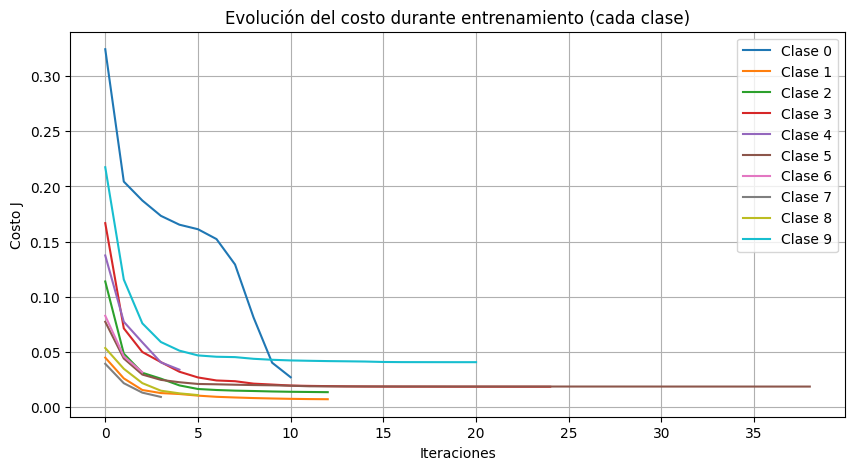

In [ ]:
plt.figure(figsize=(10,5))

for i, ch in enumerate(cost_history_all):
    plt.plot(ch, label=f'Clase {i}')

plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Evolución del costo durante entrenamiento (cada clase)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve la predicción de clase (0 a 9) usando los parámetros entrenados.
    """
    probs = sigmoid(X.dot(all_theta.T))  # probabilidad de cada clase
    p = np.argmax(probs, axis=1)         # clase con mayor probabilidad
    return p


Función predictOneVsAll lista para usar.


Precisión en entrenamiento: 97.99%
Precisión en validación: 96.51%


/tmp/ipykernel_15853/1908831495.py:6: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


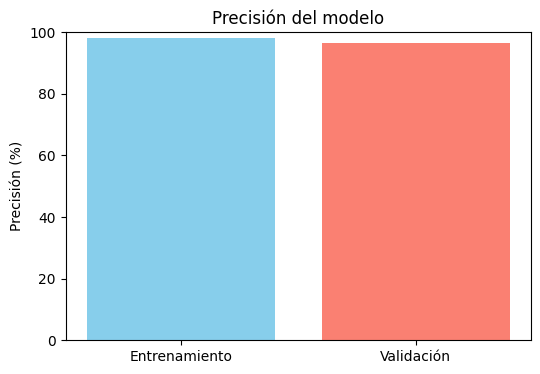

In [ ]:
# Predicciones
pred_train = predictOneVsAll(all_theta, X_train_split)
pred_val = predictOneVsAll(all_theta, X_val)

# Calcular precisión (%)
acc_train = np.mean(pred_train == y_train_split) * 100
acc_val = np.mean(pred_val == y_val) * 100

print(f"Precisión en entrenamiento: {acc_train:.2f}%")
print(f"Precisión en validación: {acc_val:.2f}%")

# Gráfico de precisión
plt.figure(figsize=(6,4))
plt.bar(['Entrenamiento', 'Validación'], [acc_train, acc_val], color=['skyblue','salmon'])
plt.ylim(0, 100)
plt.ylabel("Precisión (%)")
plt.title("Precisión del modelo")
plt.show()

In [ ]:
from PIL import Image
# Ruta de la nueva imagen
img_path = path + 'imagen.png'

# Abrir y convertir a escala de grises
img1 = Image.open(img_path).convert('L')

# Redimensionar a 28x28
img1 = img1.resize((28, 28))

# Convertir a array numpy y normalizar
img1_arr = np.array(img1) / 255.0

# Aplanar a vector (1 x 784)
img1_vec = img1_arr.flatten().reshape(1, -1)

# Agregar bias
img1_vec = np.concatenate([np.ones((1,1)), img1_vec], axis=1)

print("Dimensiones de la imagen para predicción:", img1_vec.shape)

Dimensiones de la imagen para predicción: (1, 785)


In [ ]:
pred_img1 = predictOneVsAll(all_theta, img1_vec)[0]
print("La imagen1 fue clasificada como:", pred_img1)

La imagen1 fue clasificada como: 6


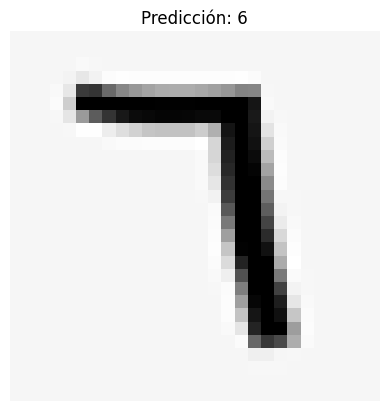

In [ ]:
plt.imshow(img1_arr, cmap='gray')
plt.title(f'Predicción: {pred_img1}')
plt.axis('off')
plt.show()